# Importação de Bibliotecas

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento do Dataset

In [56]:
df = pd.read_csv('../data/dados.csv')

# Visualizando as 5 primeiras linhas

In [57]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Ana Silva,Brasil,Amargo 70%,2026-01-05,1250.0,25
1,James Cook,USA,Milk Chocolate,2026-01-07,840.0,12
2,Elena Rossi,Italy,Gianduja Bar,2026-01-10,2100.0,30
3,Marc Petit,France,Truffles Box,2026-01-12,550.0,5
4,Hans Müller,Germany,Marzipan Dark,2026-01-15,1450.0,22


# Informações Gerais do Dataset

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   100 non-null    object 
 1   Country        100 non-null    object 
 2   Product        100 non-null    object 
 3   Date           100 non-null    object 
 4   Amount         100 non-null    float64
 5   Boxes Shipped  100 non-null    int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


# Estatística Descritiva do Dataset

In [59]:
df.describe()

,Amount,Boxes Shipped
count,100.000000,100.000000
mean,1572.600000,23.240000
std,958.848868,11.868914
min,430.000000,4.000000
25%,742.500000,12.000000
50%,1265.000000,21.500000
75%,2262.500000,33.000000
max,4200.000000,52.000000


# Verificação de Valores Nulos

In [60]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

# Número de linhas e de colunas

In [61]:
print(f'Número de linhas {df.shape[0]}. Número de colunas: {df.shape[1]}')

Número de linhas 100. Número de colunas: 6


# Renomeando as Colunas

In [62]:
nomes_colunas = {
    'Sales Person': 'Vendedor',
    'Country': 'Pais',
    'Product': 'Produto',
    'Date': 'Data',
    'Amount': 'Valor_Total',
    'Boxes Shipped': 'Caixas_Enviadas'
}

df.rename(columns=nomes_colunas, inplace=True)

df.columns

Index(['Vendedor', 'Pais', 'Produto', 'Data', 'Valor_Total',
       'Caixas_Enviadas'],
      dtype='object')

# Convertendo a coluna 'Data' de String para o tipo Datetime

In [63]:
df['Data'] = pd.to_datetime(df['Data'])

# Quais são os 5 produtos mais vendidos?

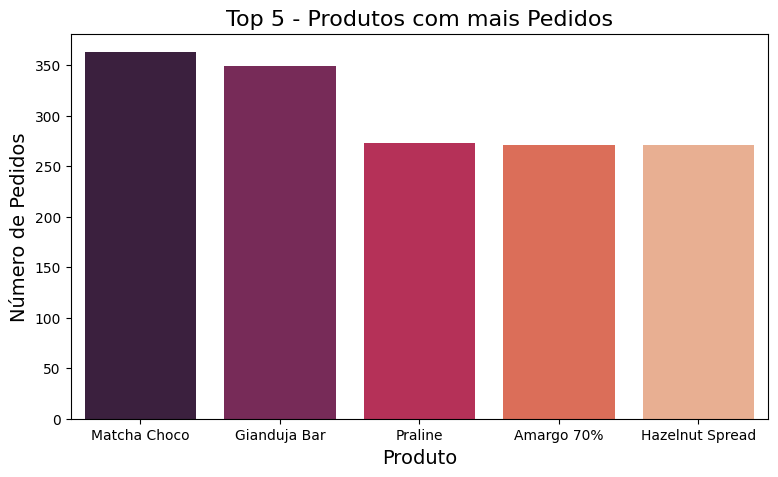

In [64]:
produtos_caixa = df.groupby('Produto', as_index=False)['Caixas_Enviadas'].sum().sort_values(by='Caixas_Enviadas', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=produtos_caixa, x='Produto', y='Caixas_Enviadas', palette='rocket', hue='Produto')
ax.set_title('Top 5 - Produtos com mais Pedidos', fontsize=16)
ax.set_xlabel('Produto', fontsize=14)
ax.set_ylabel('Número de Pedidos', fontsize=14)

plt.show()

# Qual país gerou maior faturamento?

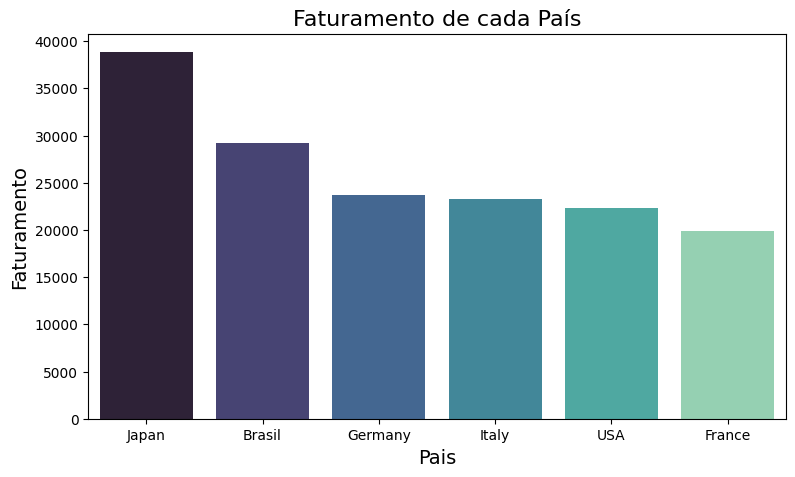

In [65]:
faturamento_pais = df.groupby('Pais', as_index=False)['Valor_Total'].sum().sort_values(by='Valor_Total', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=faturamento_pais, x='Pais', y='Valor_Total', palette='mako', hue='Pais')
ax.set_title('Faturamento de cada País', fontsize=16)
ax.set_xlabel('Pais', fontsize=14)
ax.set_ylabel('Faturamento', fontsize=14)

plt.show()

# Quais são os 5 vendedores com mais pedidos?

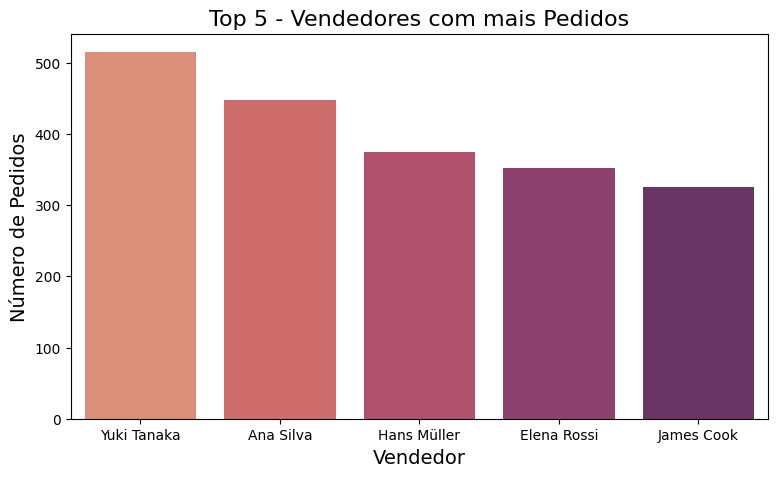

In [66]:
vendedor_pedidos = df.groupby('Vendedor', as_index=False)['Caixas_Enviadas'].sum().sort_values(by='Caixas_Enviadas', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=vendedor_pedidos, x='Vendedor', y='Caixas_Enviadas', palette='flare', hue='Vendedor')
ax.set_title('Top 5 - Vendedores com mais Pedidos', fontsize=16)
ax.set_xlabel('Vendedor', fontsize=14)
ax.set_ylabel('Número de Pedidos', fontsize=14)

plt.show()

# Quais são os 5 vendedores que mais geraram receita?

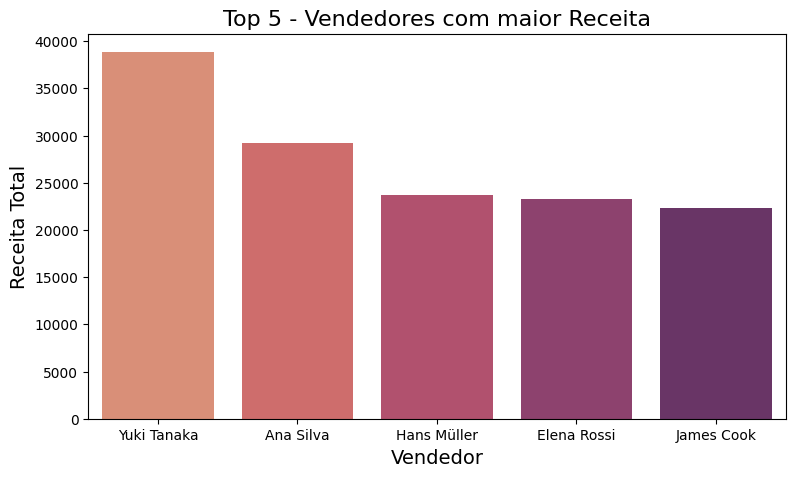

In [67]:
receita_vendedor = df.groupby('Vendedor', as_index=False)['Valor_Total'].sum().sort_values(by='Valor_Total', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=receita_vendedor, x='Vendedor', y='Valor_Total', palette='flare', hue='Vendedor')
ax.set_title('Top 5 - Vendedores com maior Receita', fontsize=16)
ax.set_xlabel('Vendedor', fontsize=14)
ax.set_ylabel('Receita Total', fontsize=14)

plt.show()

# Como esta distribuído o volume de entrega entre os países?

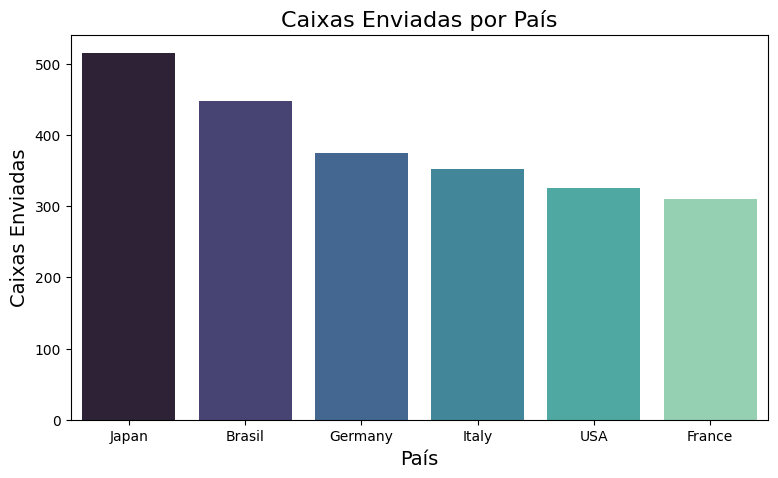

In [68]:
caixas_pais = df.groupby('Pais', as_index=False)['Caixas_Enviadas'].sum().sort_values(by='Caixas_Enviadas', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=caixas_pais, x='Pais', y='Caixas_Enviadas', palette='mako', hue='Pais')
ax.set_title('Caixas Enviadas por País', fontsize=16)
ax.set_xlabel('País', fontsize=14)
ax.set_ylabel('Caixas Enviadas', fontsize=14)

plt.show()

# Quais são os produtos que mais geraram receita?

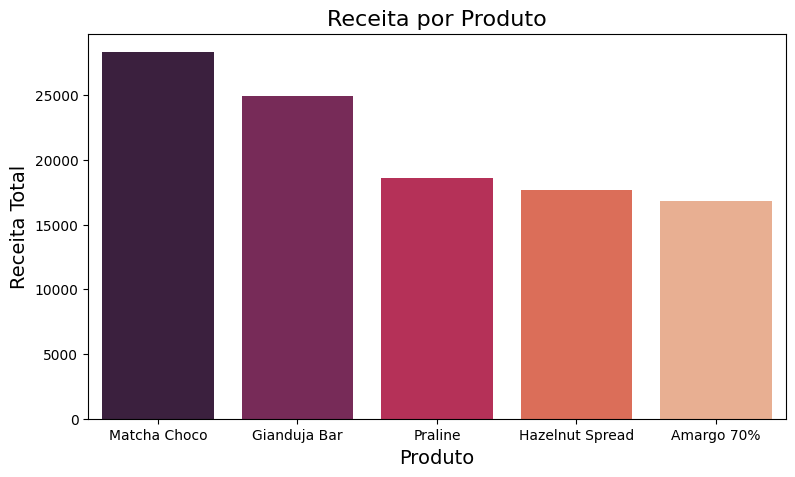

In [69]:
receita_produto = df.groupby('Produto', as_index=False)['Valor_Total'].sum().sort_values(by='Valor_Total', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(data=receita_produto, x='Produto', y='Valor_Total', palette='rocket', hue='Produto')
ax.set_title('Receita por Produto', fontsize=16)
ax.set_xlabel('Produto', fontsize=14)
ax.set_ylabel('Receita Total', fontsize=14)

plt.show()